# Coal GCV — Exploratory Data Analysis

Distribution, correlation, and relationship analysis of the four proximate-analysis features against GCV.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.config import CLEAN_DATA_PATH, FEATURE_COLUMNS, TARGET_COLUMN

df = pd.read_csv(CLEAN_DATA_PATH)
df.describe()

,Moisture,Volatile_matter,Fixed_Carbon,Std.Ash,GCV
count,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000
mean,8.093585,32.289515,48.784272,10.832628,25.475186
std,9.923789,6.331508,11.031056,5.986231,6.574647
min,0.400000,3.800000,4.100000,0.900000,4.823807
25%,2.200000,29.100000,42.700000,6.400000,22.667128
50%,3.500000,33.300000,49.300000,9.600000,27.634916
75%,9.300000,36.530000,55.570000,14.050000,30.167367
max,49.600000,55.700000,87.000000,32.900000,34.854731


## Feature distributions

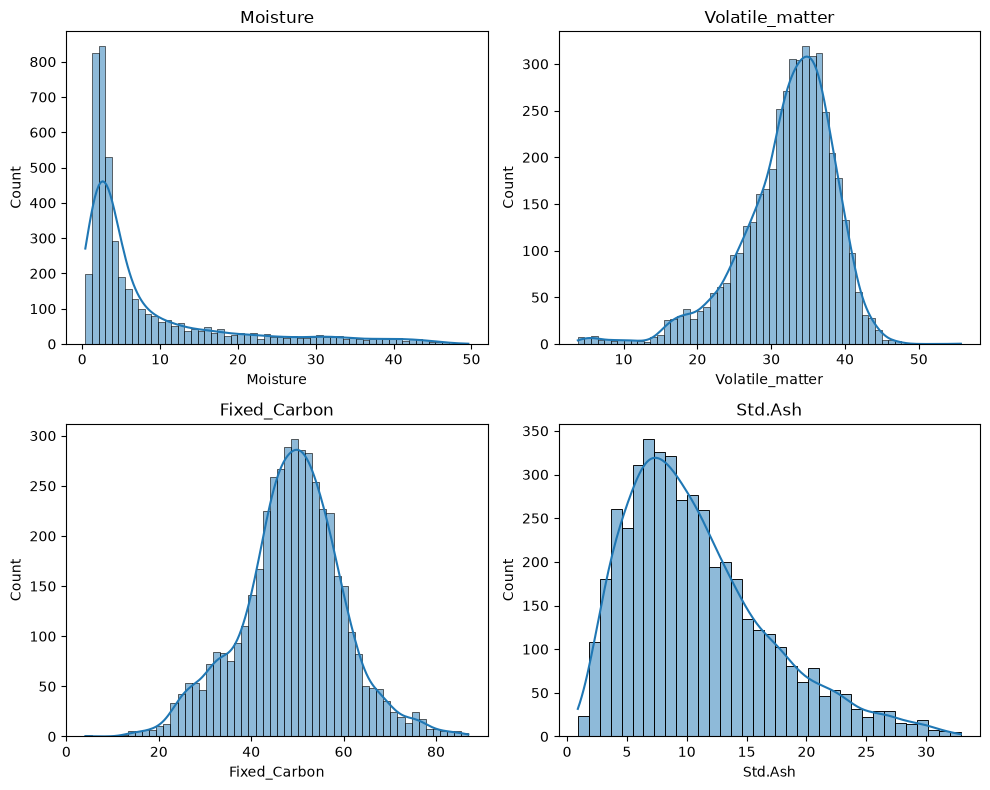

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, column in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()

## Correlation heatmap

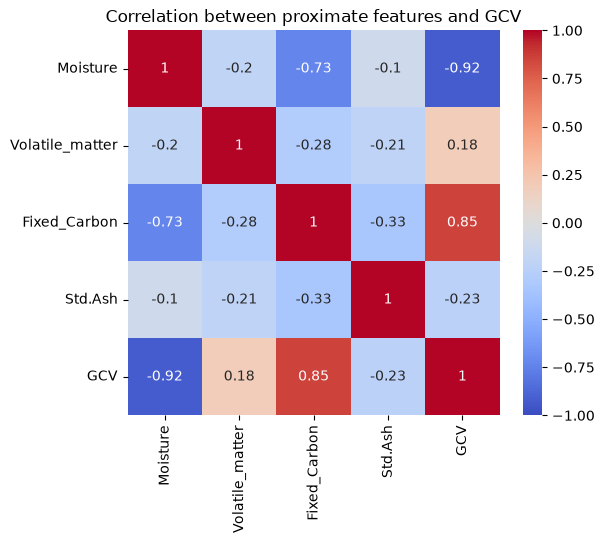

In [3]:
correlation = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between proximate features and GCV")
plt.show()

## GCV vs. each feature

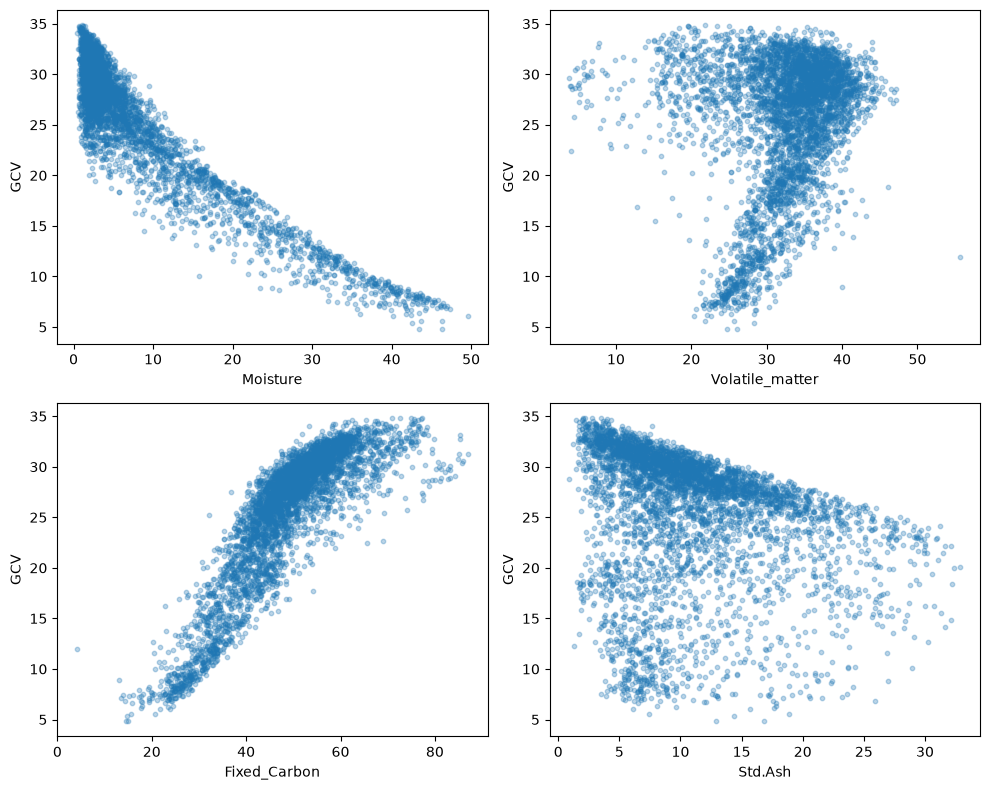

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, column in zip(axes.flatten(), FEATURE_COLUMNS):
    ax.scatter(df[column], df[TARGET_COLUMN], alpha=0.3, s=10)
    ax.set_xlabel(column)
    ax.set_ylabel(TARGET_COLUMN)
plt.tight_layout()
plt.show()

## Observations

- Fixed Carbon typically shows the strongest positive correlation with GCV; Moisture and Ash typically show negative correlation, consistent with combustion chemistry.
- The four features sum to 100% by construction (proximate analysis convention).
- Findings here inform the Analytics dashboard page.